### Setup and Data Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import MissingIndicator, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing %:")
print((df.isnull().mean() * 100).round(2))

Shape: (891, 3)

First 5 rows:
   Survived   Age     Fare
0         0  22.0   7.2500
1         1  38.0  71.2833
2         1  26.0   7.9250
3         1  35.0  53.1000
4         0  35.0   8.0500

Missing %:
Survived     0.00
Age         19.87
Fare         0.00
dtype: float64


### Train-Test-Split

In [2]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("\nMissing in X_train:")
print(X_train.isnull().sum())

X_train shape: (712, 2)
X_test shape : (179, 2)

Missing in X_train:
Age     148
Fare      0
dtype: int64


### Baseline Model - Without Missing Indicator

In [3]:
# baseline: just impute with mean, no indicator

si_baseline = SimpleImputer()   # default strategy = mean

X_train_base = si_baseline.fit_transform(X_train)
X_test_base  = si_baseline.transform(X_test)

clf_base = LogisticRegression()
clf_base.fit(X_train_base, y_train)
y_pred_base = clf_base.predict(X_test_base)

baseline_acc = accuracy_score(y_test, y_pred_base)
print(f"Baseline accuracy (no indicator): {baseline_acc:.4f}")

Baseline accuracy (no indicator): 0.6145


### Way-1 : MissingIndicator

In [4]:
# MissingIndicator → creates a separate boolean array
# marking where values were missing

mi = MissingIndicator()

# fit on train → learns WHICH columns have missing values
mi.fit(X_train)

# see which column indices have missing values
print("Column indices with missing values:")
print(mi.features_)
# output: [0] → only column index 0 (Age) has missing values
# Fare has no missing → not included

Column indices with missing values:
[0]


In [5]:
# transform → creates boolean array
# True  = was missing
# False = was present

X_train_missing = mi.transform(X_train)
X_test_missing  = mi.transform(X_test)

print("Missing indicator for first 10 rows of X_train:")
print(X_train_missing[:10])

print(f"\nShape of indicator: {X_train_missing.shape}")
print(f"True count  (missing) : {X_train_missing.sum()}")
print(f"False count (present) : {(~X_train_missing).sum()}")

Missing indicator for first 10 rows of X_train:
[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]]

Shape of indicator: (712, 1)
True count  (missing) : 148
False count (present) : 564


In [6]:
# add indicator as new column to X_train and X_test
X_train = X_train.copy()
X_test  = X_test.copy()

X_train['Age_NA'] = X_train_missing   # True/False column
X_test['Age_NA']  = X_test_missing

print("X_train with missing indicator:")
print(X_train.head(10))

print(f"\nAge_NA distribution:")
print(X_train['Age_NA'].value_counts())

X_train with missing indicator:
      Age     Fare  Age_NA
30   40.0  27.7208   False
10    4.0  16.7000   False
873  47.0   9.0000   False
182   9.0  31.3875   False
876  20.0   9.8458   False
213  30.0  13.0000   False
157  30.0   8.0500   False
780  13.0   7.2292   False
572  36.0  26.3875   False
77    NaN   8.0500    True

Age_NA distribution:
Age_NA
False    564
True     148
Name: count, dtype: int64


In [7]:
# now impute the actual missing values
# indicator is already added → now fill NaN
si = SimpleImputer()   # fills Age NaN with mean

X_train_trf = si.fit_transform(X_train)   # fits on train → transforms
X_test_trf  = si.transform(X_test)        # same transformation on test

print("X_train after imputation + indicator:")
print(X_train_trf[:5])
print(f"\nShape: {X_train_trf.shape}")
print(f"Missing values remaining: {np.isnan(X_train_trf).sum()}")

X_train after imputation + indicator:
[[40.     27.7208  0.    ]
 [ 4.     16.7     0.    ]
 [47.      9.      0.    ]
 [ 9.     31.3875  0.    ]
 [20.      9.8458  0.    ]]

Shape: (712, 3)
Missing values remaining: 0


In [8]:
# train model with indicator
clf_ind = LogisticRegression()
clf_ind.fit(X_train_trf, y_train)
y_pred_ind = clf_ind.predict(X_test_trf)

indicator_acc = accuracy_score(y_test, y_pred_ind)

print("=" * 45)
print("ACCURACY COMPARISON")
print("=" * 45)
print(f"Without indicator : {baseline_acc:.4f}")
print(f"With indicator    : {indicator_acc:.4f}")
print(f"Improvement       : {(indicator_acc - baseline_acc)*100:+.2f}%")

ACCURACY COMPARISON
Without indicator : 0.6145
With indicator    : 0.6313
Improvement       : +1.68%


### Way-2 : SimpleImputer with add_imputer=True

In [9]:
# SimpleImputer(add_indicator=True) does BOTH in one step:
# 1. Imputes missing values with mean
# 2. Adds indicator columns automatically

# fresh split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2
)

si_with_indicator = SimpleImputer(
    strategy='mean',    # fill missing with mean
    add_indicator=True  # automatically add True/False columns
)

# fit on train → learns mean AND which columns have missing
si_with_indicator.fit(X_train)

# transform
X_train_auto = si_with_indicator.fit_transform(X_train)
X_test_auto  = si_with_indicator.transform(X_test)

print("Shape before:", X_train.shape)
print("Shape after :", X_train_auto.shape)
print("\nX_train after (first 5 rows):")
print(X_train_auto[:5])

Shape before: (712, 2)
Shape after : (712, 3)

X_train after (first 5 rows):
[[40.     27.7208  0.    ]
 [ 4.     16.7     0.    ]
 [47.      9.      0.    ]
 [ 9.     31.3875  0.    ]
 [20.      9.8458  0.    ]]


In [10]:
# train and evaluate
clf_auto = LogisticRegression()
clf_auto.fit(X_train_auto, y_train)
y_pred_auto = clf_auto.predict(X_test_auto)

auto_acc = accuracy_score(y_test, y_pred_auto)

print("=" * 50)
print("FINAL ACCURACY COMPARISON")
print("=" * 50)
print(f"No indicator (baseline)    : {baseline_acc:.4f}")
print(f"Manual indicator           : {indicator_acc:.4f}")
print(f"Auto indicator (add_indicator=True): {auto_acc:.4f}")

FINAL ACCURACY COMPARISON
No indicator (baseline)    : 0.6145
Manual indicator           : 0.6313
Auto indicator (add_indicator=True): 0.6313


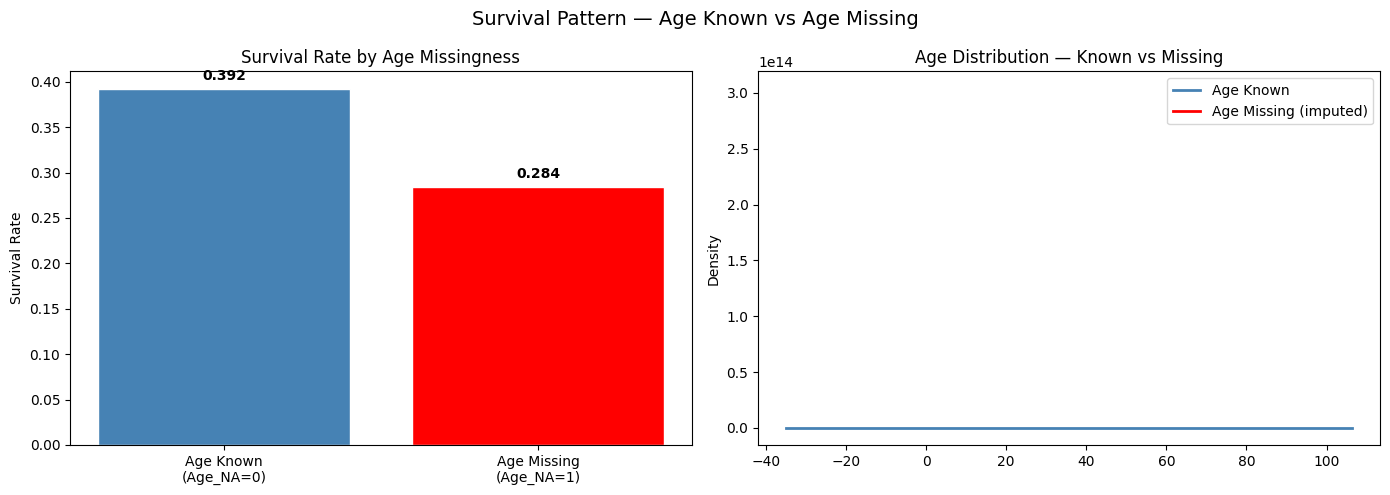


Survival rate when age is KNOWN  : 0.392
Survival rate when age is MISSING: 0.284


In [11]:
X_train_df = pd.DataFrame(X_train_auto,
                           columns=['Age','Fare','Age_NA'])
X_train_df['Survived'] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Survival Pattern — Age Known vs Age Missing", fontsize=14)

# survival rate by Age_NA flag
survival_by_na = X_train_df.groupby('Age_NA')['Survived'].mean()

axes[0].bar(['Age Known\n(Age_NA=0)', 'Age Missing\n(Age_NA=1)'],
            survival_by_na.values,
            color=['steelblue','red'],
            edgecolor='white')
axes[0].set_title("Survival Rate by Age Missingness")
axes[0].set_ylabel("Survival Rate")
for i, v in enumerate(survival_by_na.values):
    axes[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Age distribution — known vs imputed
X_train_df[X_train_df['Age_NA']==0]['Age'].plot.kde(
    ax=axes[1], color='steelblue', label='Age Known', linewidth=2
)
X_train_df[X_train_df['Age_NA']==1]['Age'].plot.kde(
    ax=axes[1], color='red', label='Age Missing (imputed)', linewidth=2
)
axes[1].set_title("Age Distribution — Known vs Missing")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nSurvival rate when age is KNOWN  :", survival_by_na[0].round(3))
print("Survival rate when age is MISSING:", survival_by_na[1].round(3))